# CHRONO-Fair: End-to-End Reproducible Analysis

Anytime-valid counterfactual flip monitoring for clinical machine learning.

This notebook reproduces every experiment and figure in the paper. It uses two data sources.

1. **Synthetic stream** (`data/texas100x_synthetic_stream.csv`). Generated by the calibrated synthesiser. Its demographic mix and class balance match the published Texas-100X statistics. It is not the real discharge data.
2. **Real audit artefacts** (`data/real_texas100x_audit_artifacts.json`). Real 1000-iteration bootstrap confidence intervals and 20-resample fluctuation arrays computed by the parent repository on the full real Texas-100X dataset (925,128 records).

Every numerical claim in the paper is produced by a cell below. No result is hard-coded.

## 0. Environment setup

In [1]:
import os, sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Resolve repository root so the notebook runs from any directory
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if os.path.basename(os.getcwd()) != 'chrono_fair':
    ROOT = os.getcwd()
sys.path.insert(0, ROOT)
FIG = os.path.join(ROOT, 'chrono_fair_figures')
print('repo root :', ROOT)
print('figures   :', FIG)
import chrono_fair
print('chrono_fair version:', chrono_fair.__version__)

repo root : /home/user/Length-of-stay-prediction-using-Texas100x--Fairness
figures   : /home/user/Length-of-stay-prediction-using-Texas100x--Fairness/chrono_fair_figures
chrono_fair version: 0.1.0


## 1. Build the dataset

Writes the synthetic stream and copies the real audit artefacts into `chrono_fair/data/`. See `data/DATA_CARD.md` for provenance.

In [2]:
from chrono_fair.data.build_dataset import main as build_data
build_data()
df = pd.read_csv(os.path.join(ROOT, 'chrono_fair', 'data',
                              'texas100x_synthetic_stream.csv'))
print('\nsynthetic stream shape:', df.shape)
display(df.head())
print('\nrace mix:'); display(df['race'].value_counts())
print('extended-stay balance:', round(df['y_ext'].mean(), 3))

Wrote /home/user/Length-of-stay-prediction-using-Texas100x--Fairness/chrono_fair/data/texas100x_synthetic_stream.csv  (30000 rows, 21 columns)
  drift onset at arrival index 18000
  race mix: {'White': 14311, 'Hispanic': 9145, 'Black': 3872, 'Asian/PI': 1475, 'Other': 1197}


  split train: n= 21000  ext-stay=0.451  -> /home/user/Length-of-stay-prediction-using-Texas100x--Fairness/chrono_fair/data/splits/texas100x_synthetic_train.csv
  split val  : n=  4500  ext-stay=0.465  -> /home/user/Length-of-stay-prediction-using-Texas100x--Fairness/chrono_fair/data/splits/texas100x_synthetic_val.csv


  split test : n=  4500  ext-stay=0.444  -> /home/user/Length-of-stay-prediction-using-Texas100x--Fairness/chrono_fair/data/splits/texas100x_synthetic_test.csv
  wrote /home/user/Length-of-stay-prediction-using-Texas100x--Fairness/chrono_fair/data/splits/split_manifest.json
Wrote /home/user/Length-of-stay-prediction-using-Texas100x--Fairness/chrono_fair/data/real_texas100x_audit_artifacts.json  (real bootstrap CIs and fluctuation arrays)
Wrote /home/user/Length-of-stay-prediction-using-Texas100x--Fairness/chrono_fair/data/DATA_CARD.md

synthetic stream shape: (30000, 21)


,arrival,patient_id,race,sex,ethnicity,age_group,age_years,y_los,y_ext,x0,...,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11
0,2024-01-01 00:00:00,0,Hispanic,Female,Hispanic,Middle-aged,45.111351,3.693544,0,0.929367,...,0.131234,1.564216,-0.772258,-0.887159,0.051568,1.429852,-1.272782,0.348748,-0.379864,-1.650470
1,2024-01-01 00:05:00,1,White,Female,Hispanic,Young Adult,34.548489,2.817491,0,-0.128328,...,0.077673,-0.645443,-0.179540,-0.757022,1.355664,-1.223510,-0.016776,-0.518328,-0.404484,-0.199295
2,2024-01-01 00:10:00,2,Hispanic,Male,Hispanic,Elderly,75.693672,3.610622,0,-0.324353,...,1.790766,-0.542092,0.924117,-0.960343,0.817224,-0.611412,-0.072941,-1.350695,-1.440086,-0.831340
3,2024-01-01 00:15:00,3,Hispanic,Female,Hispanic,Middle-aged,54.914548,3.377891,0,1.421746,...,0.687599,1.599163,-0.148978,-0.714138,-0.479351,0.506910,-0.359110,1.369457,-0.536771,0.974682
4,2024-01-01 00:20:00,4,White,Female,Non-Hispanic,Elderly,72.509666,3.269222,0,0.476223,...,-1.071803,-2.369259,0.086515,-0.605710,0.329987,0.452697,-0.591969,-0.847836,0.006694,-2.039053



race mix:


race
White       14311
Hispanic     9145
Black        3872
Asian/PI     1475
Other        1197
Name: count, dtype: int64

extended-stay balance: 0.452


## 2. Component check: the four estimators

A quick functional check that each of the four estimators runs and returns the expected object type.

In [3]:
from chrono_fair.flip_hazard import kaplan_meier_curve, logrank_two_groups
from chrono_fair.e_process import EProcessMonitor
from chrono_fair.decomposition import ensemble_decompose
from chrono_fair.rcap import rank_shift, wasserstein_rcap_ci

rng = np.random.default_rng(0)
z = (rng.random(800) < 0.12).astype(int)
km = kaplan_meier_curve(np.arange(800.0), z)
print('Flip Hazard  : KM final survival =', round(km['S'].iloc[-1], 4))

mon = EProcessMonitor(rho0=0.05, alpha=0.05)
for v in (rng.random(3000) < 0.15).astype(int):
    mon.update(int(v))
print('E-process    : alarm at patient', mon.alarm_at)

pa = rng.random((7, 500)); pc = rng.random((7, 500))
dec = ensemble_decompose(pa, pc)
print('Decomposition: mean flip mass =', round(dec['p_flip_bar'].mean(), 4))

d = rng.normal(0, 0.1, 400)
m, lo, hi = wasserstein_rcap_ci(d)
print('RCAP         : W1 =', round(m, 4), 'CI =', (round(lo,4), round(hi,4)))

Flip Hazard  : KM final survival = 0.5766
E-process    : alarm at patient 211
Decomposition: mean flip mass = 0.5091
RCAP         : W1 = 0.0764 CI = (0.0708, 0.0821)


## 3. Architecture and concept diagrams

The framework architecture and the VFR-Audit to CHRONO-Fair conceptual mapping.

In [4]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp0_architecture_diagram import main as _m
_m()

Wrote architecture figure.


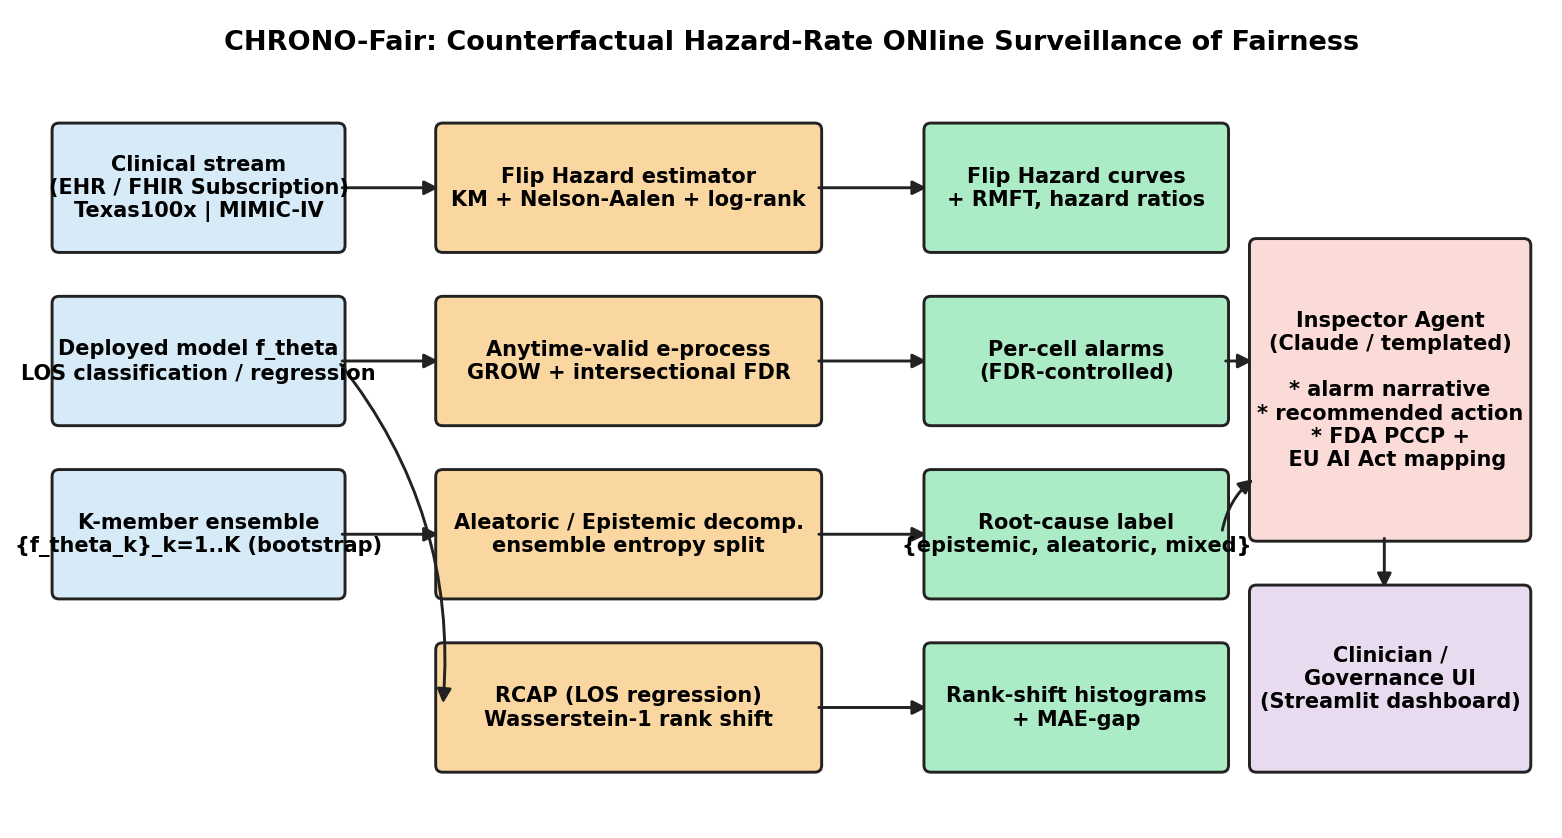

In [5]:
display(Image(filename=os.path.join(FIG, 'fig0_architecture.png')))

## 3b. VFR-Audit to CHRONO-Fair concept

VFR-Audit is a static batch scalar. CHRONO-Fair is the streaming extension; the scalar VFR is recovered as 1 - S at the audit horizon.

In [6]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp0b_concept_diagram import main as _m
_m()

Wrote fig_concept_vfr_to_chrono.png


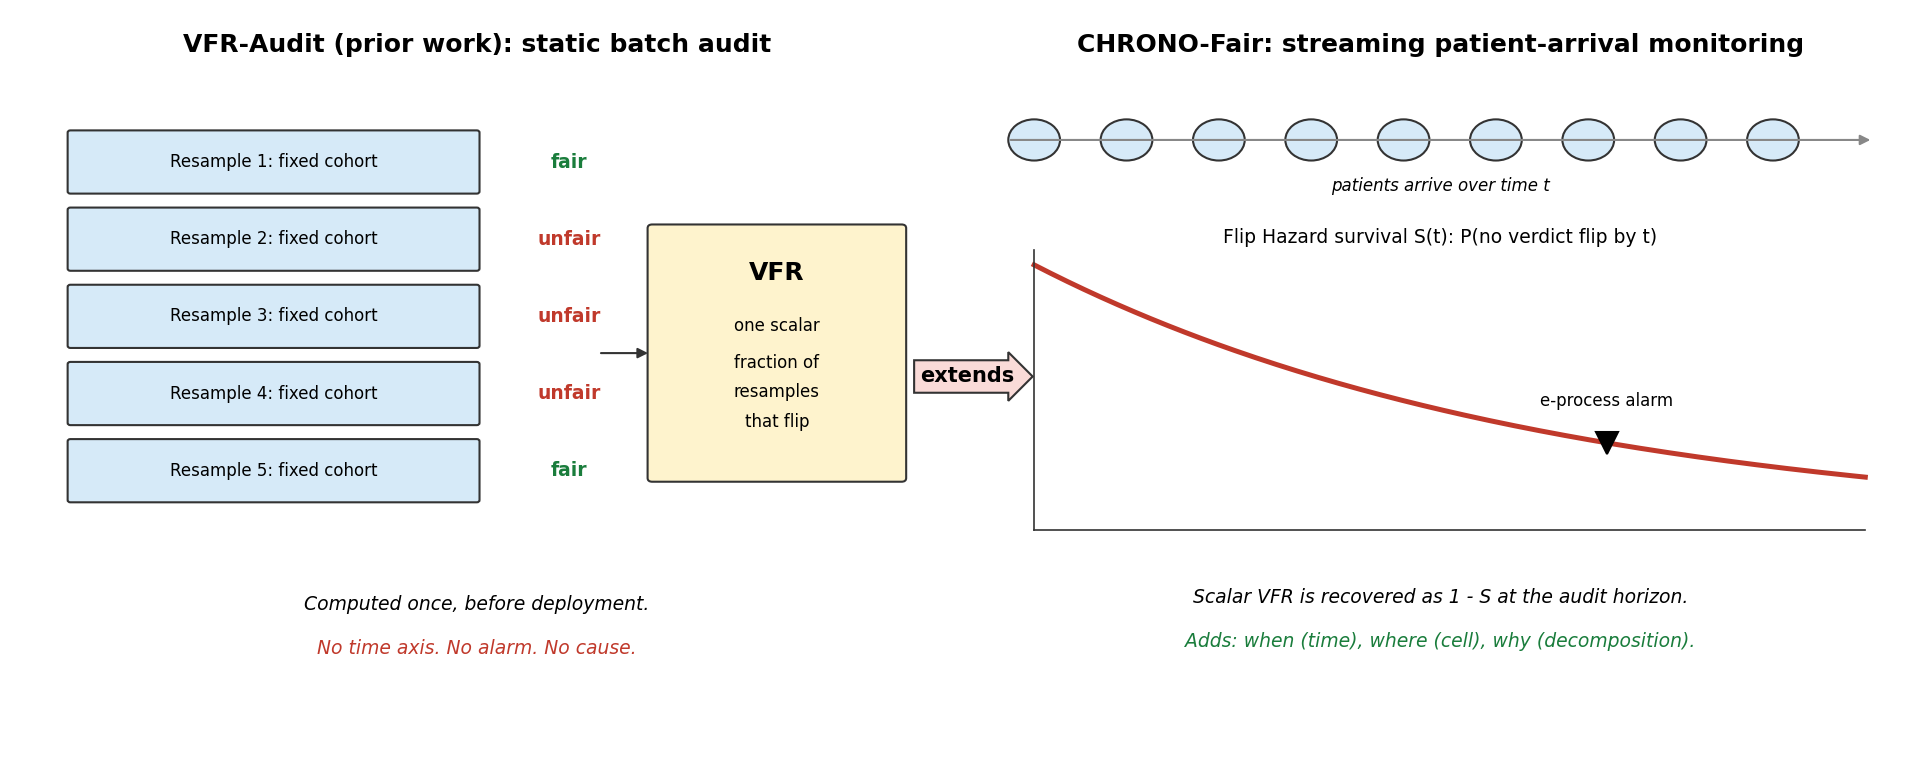

In [7]:
display(Image(filename=os.path.join(FIG, 'fig_concept_vfr_to_chrono.png')))

## 4. Experiment 1: detection delay

Patients-to-alarm after an injected drift, CHRONO-Fair against ADWIN, Davis-ADWIN, a periodic batch test, and static VFR.

In [8]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp1_detection_delay import main as _m
_m()

Sanity (no disparity) -- CHRONO-Fair false-alarm rate: 0.0


=== Experiment 1: Detection Delay ===
                mean  median    std  count
method                                    
ADWIN (k=1)   3878.1  3737.0  731.1     21
ADWIN (k=25)  3926.9  3759.0  712.6     21
CHRONO-Fair    837.4   828.0  220.8     50
Davis-ADWIN   3903.8  3749.0  718.6     21
Periodic-500   499.0   499.0    0.0     24
Static-VFR       NaN     NaN    NaN      0
Wrote /home/user/Length-of-stay-prediction-using-Texas100x--Fairness/chrono_fair/experiments/../../chrono_fair_figures/fig1_detection_delay.png


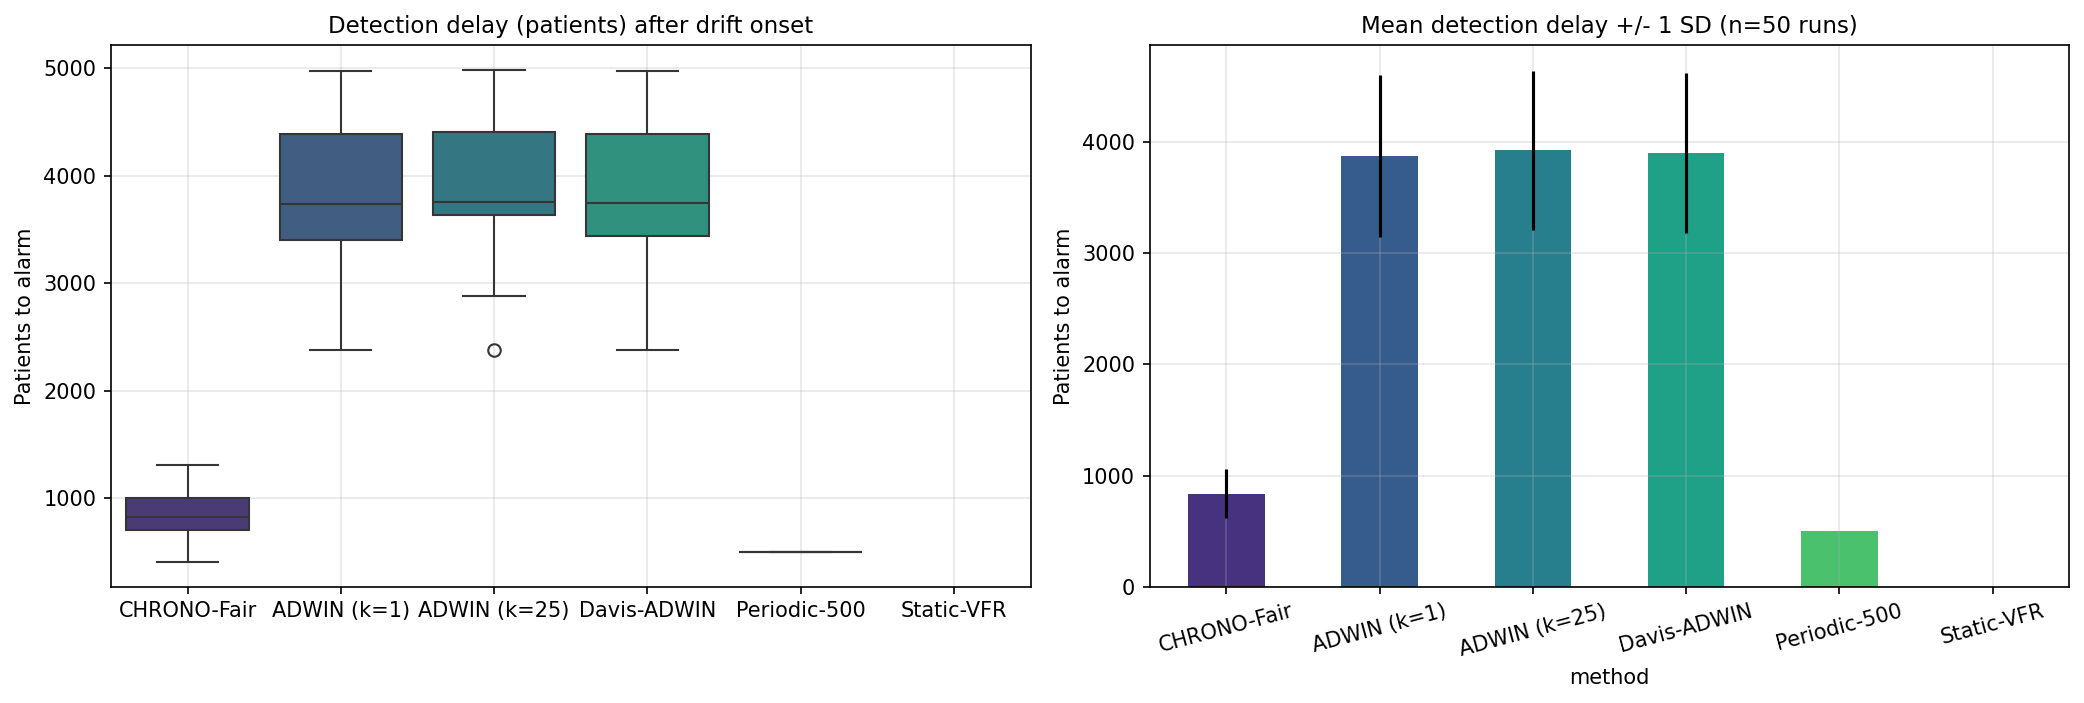

In [9]:
display(Image(filename=os.path.join(FIG, 'fig1_detection_delay.png')))

## 5. Experiment 2: aleatoric/epistemic decomposition

Controlled validation of the decomposition, and the ML-driven track that yields mixed root causes.

In [10]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp2_decomposition_accuracy import main as _m
_m()

=== Track 1: Controlled validation ===
predicted  aleatoric  epistemic  mixed  none
truth                                       
aleatoric         30          0      0     0
epistemic          0         30      0     0
mixed              0          0     30     0
Accuracy: 100.0%


=== Track 2: ML-driven validation ===
predicted  aleatoric  epistemic  mixed  none
truth                                       
aleatoric         14          0      1     0
epistemic          9          0      6     0
mixed             10          0      5     0
Accuracy: 42.2%


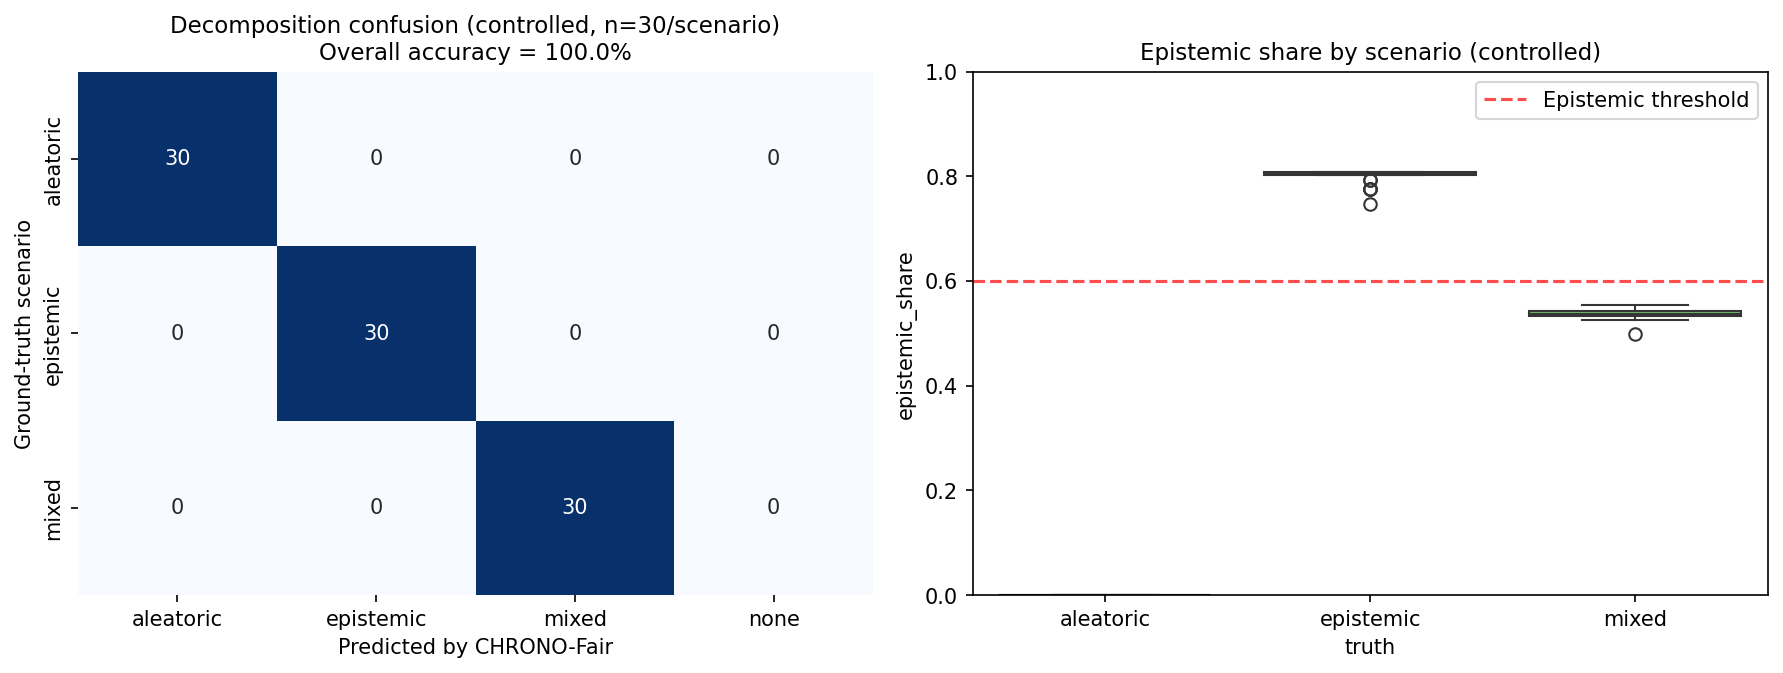

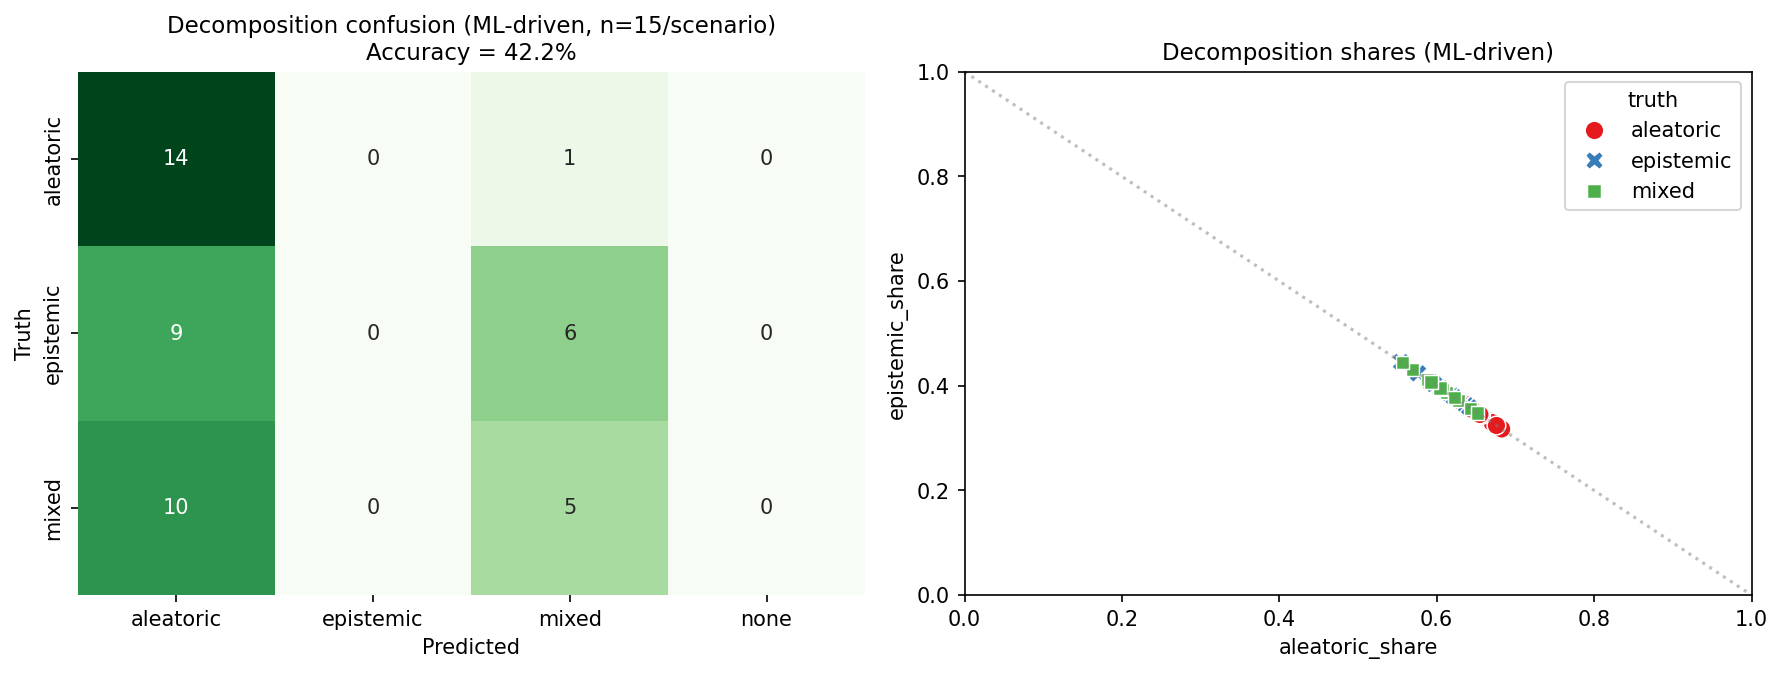

In [11]:
display(Image(filename=os.path.join(FIG, 'fig2_decomposition_confusion.png')))
display(Image(filename=os.path.join(FIG, 'fig2b_synthetic_validation.png')))

## 6. Experiment 3: Flip Hazard survival

Group-stratified Kaplan-Meier flip survival, intersectional curves, and the RMFT against scalar VFR.

In [12]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp3_flip_hazard_curves import main as _m
_m()

=== RMFT (race) ===
    race    n  VFR_scalar   RMFT_5000  final_no_flip_S
   White 7214    0.078043 4817.310972         0.674933
   Black 1946    0.190134 2459.437829         0.270703
Hispanic 4518    0.200531 3836.882552         0.152960
Asian/PI  734    0.065395 3336.982136         0.620663
   Other  588    0.066327 3940.246209         0.768101

=== Log-rank tests: White vs other races ===
Black     : chi^2=1675.49, p=0.00e+00
Hispanic  : chi^2=1248.21, p=0.00e+00
Asian/PI  : chi^2=456.33, p=0.00e+00
Other     : chi^2=455.75, p=0.00e+00


Saved Flip Hazard figures.


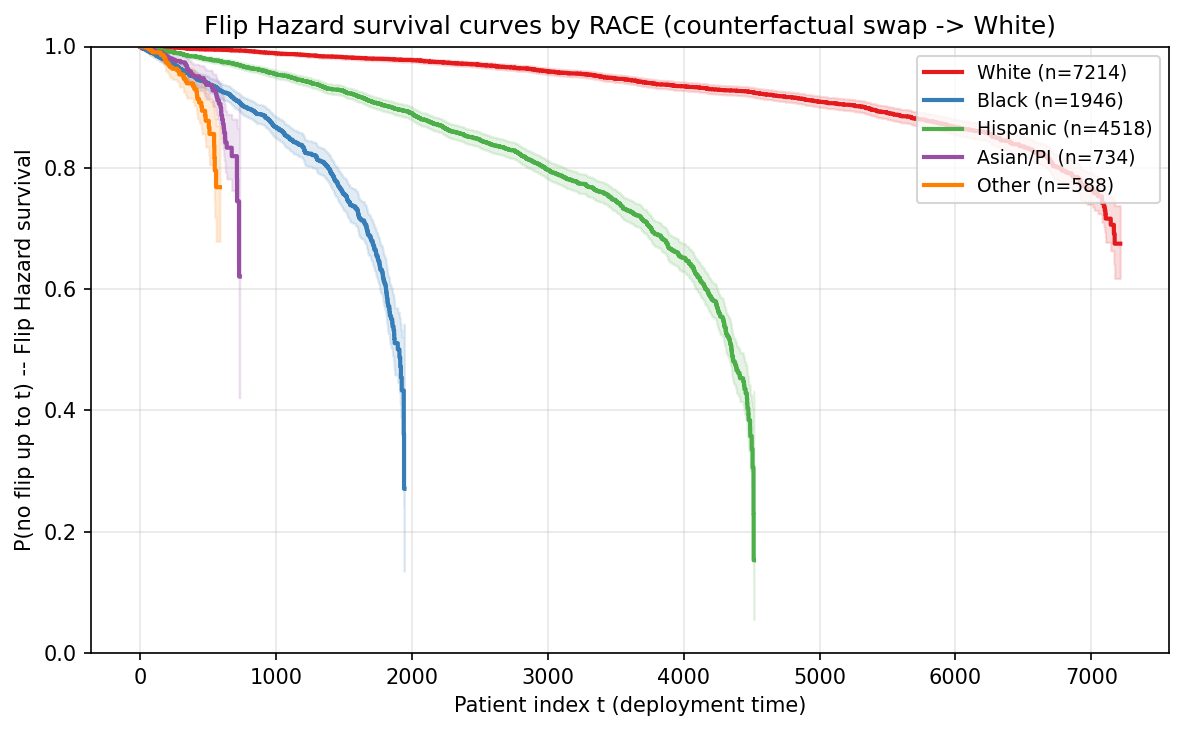

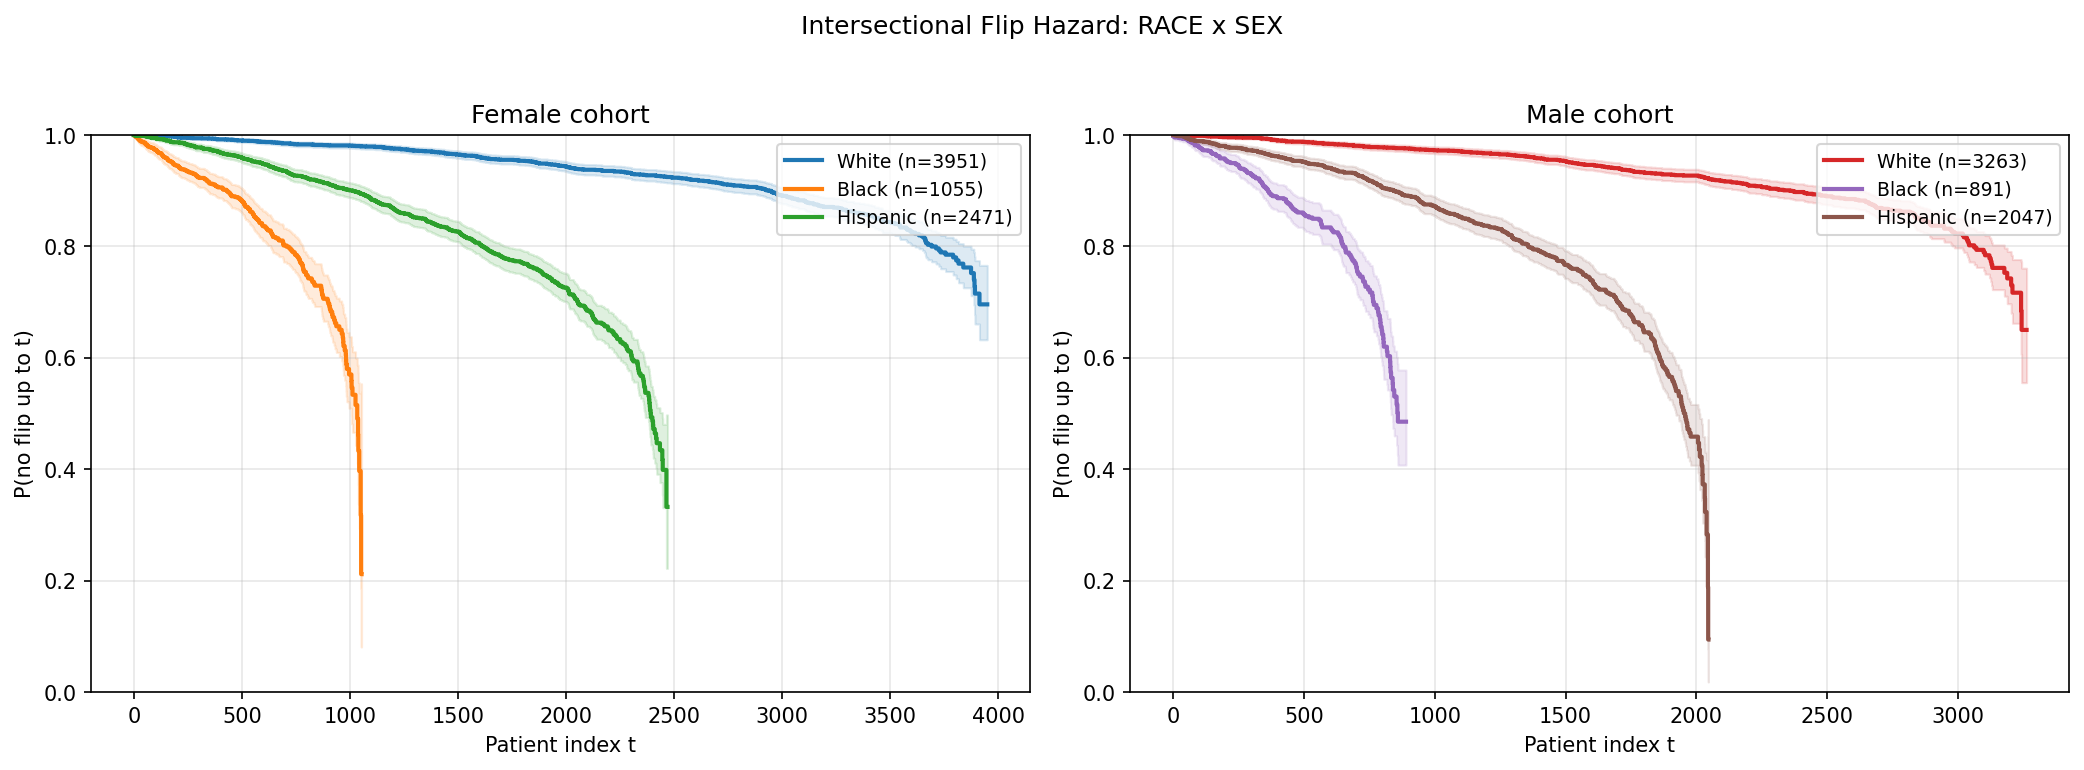

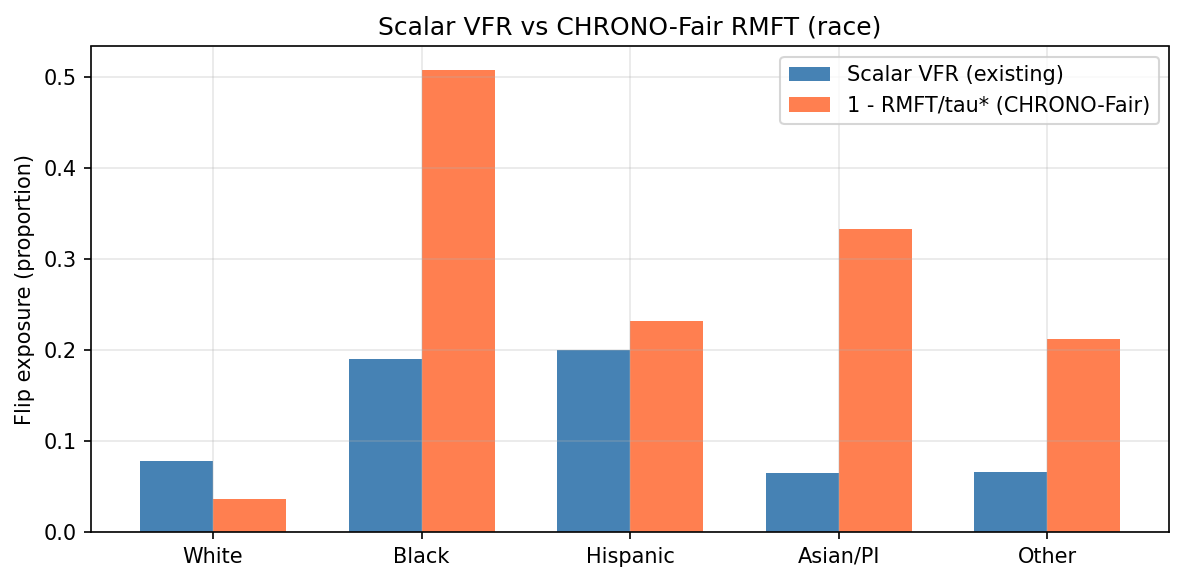

In [13]:
display(Image(filename=os.path.join(FIG, 'fig3_km_curves_race.png')))
display(Image(filename=os.path.join(FIG, 'fig3_km_curves_intersectional.png')))
display(Image(filename=os.path.join(FIG, 'fig3b_rmft_vs_vfr.png')))

## 7. Experiment 4: RCAP for length-of-stay regression

Wasserstein-1 counterfactual rank shift, with bootstrap CIs, against the group-MAE comparator.

In [14]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp4_rcap_los import main as _m
_m()

=== RCAP (race) ===
 group_a group_aprime    n  mean_rank_shift  abs_mean_rank_shift  rcap_W1
Asian/PI        Black  552         0.007682             0.008360 0.008360
Asian/PI     Hispanic  552        -0.006824             0.011797 0.011797
Asian/PI        Other  552        -0.005197             0.014616 0.014616
Asian/PI        White  552        -0.003814             0.014172 0.014172
   Black     Asian/PI 1488         0.007781             0.009454 0.009454
   Black     Hispanic 1488        -0.013859             0.014967 0.014967
   Black        Other 1488         0.001943             0.013052 0.013052
   Black        White 1488        -0.011001             0.016285 0.016285
Hispanic     Asian/PI 3643         0.021993             0.023155 0.023155
Hispanic        Black 3643         0.014332             0.015277 0.015277
Hispanic        Other 3643         0.016774             0.017582 0.017582
Hispanic        White 3643         0.003225             0.006605 0.006605
   Other     Asian

=== RCAP 95% CI (against White) ===
    race    n  rcap_W1  ci_low_95  ci_high_95
   White 5818 0.000000   0.000000    0.000000
   Black 1488 0.016285   0.015714    0.016874
Hispanic 3643 0.006605   0.006437    0.006765
Asian/PI  552 0.014172   0.013259    0.015102
   Other  499 0.004904   0.004581    0.005246


Saved RCAP figures.
=== RCAP vs MAE gap ===
    race      mae  rcap_W1  mae_gap_vs_white
   White 0.395760      NaN          0.000000
   Black 0.402253 0.016285          0.006493
Hispanic 0.396327 0.006605          0.000567
Asian/PI 0.402000 0.014172          0.006240


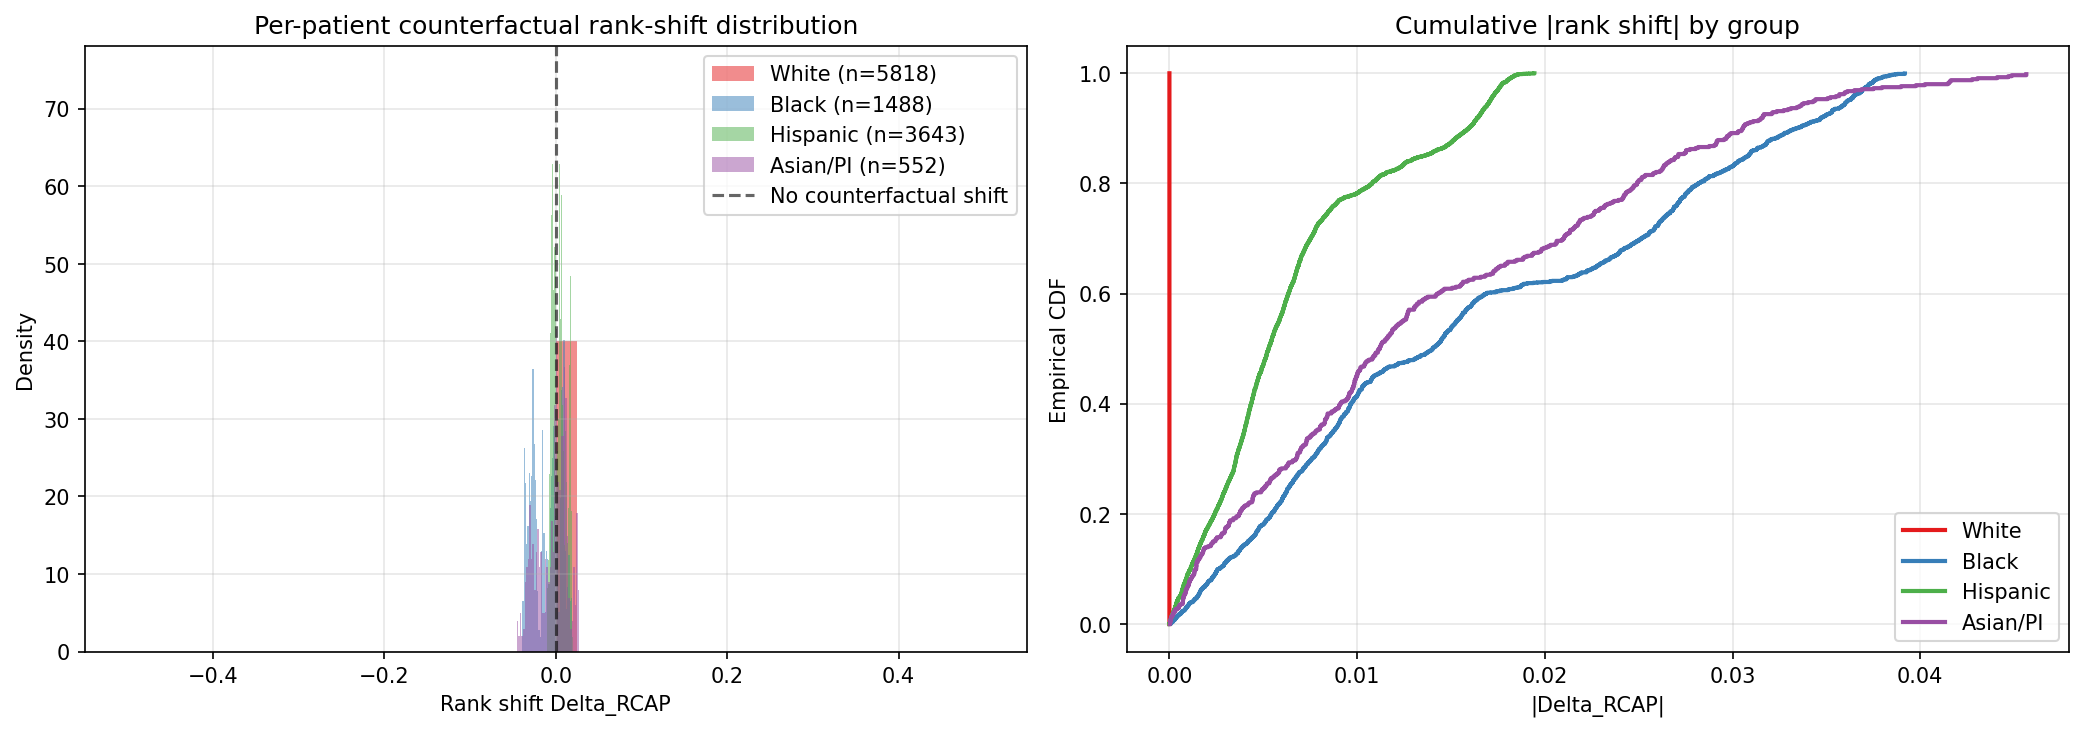

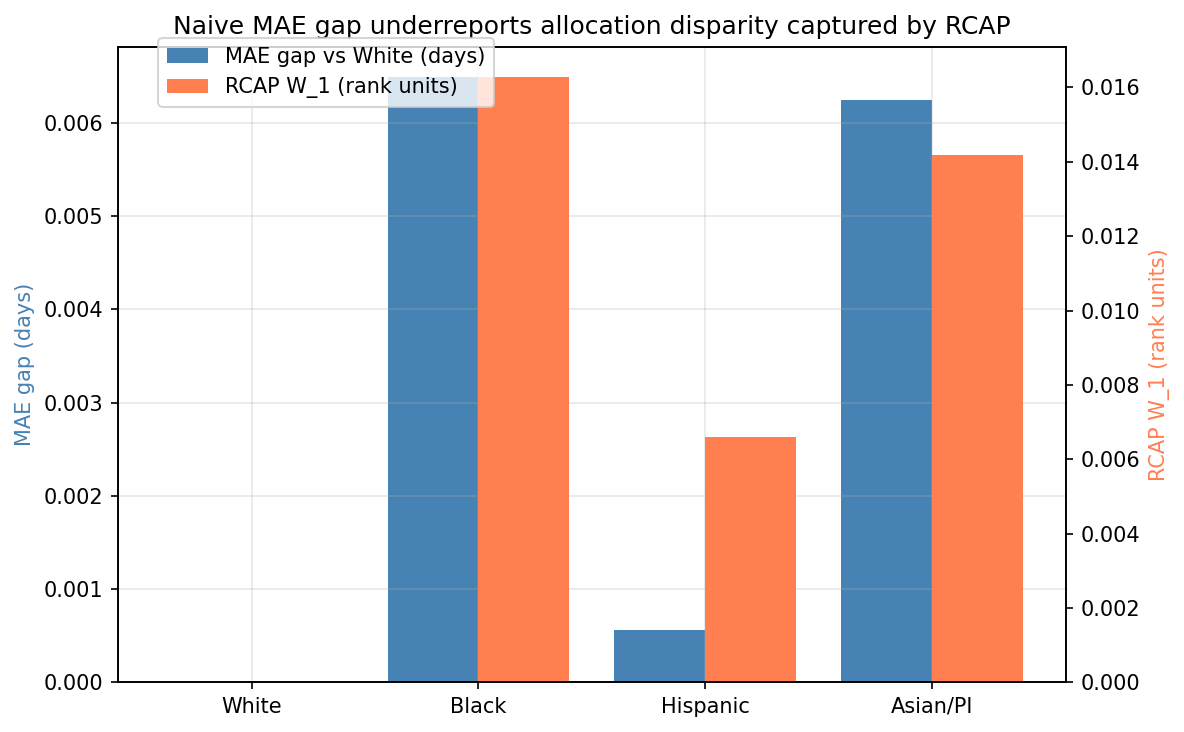

In [15]:
display(Image(filename=os.path.join(FIG, 'fig4_rcap_rank_shift.png')))
display(Image(filename=os.path.join(FIG, 'fig4b_rcap_vs_mae_gap.png')))

## 8. Experiment 5: false-alarm calibration and ablation

Empirical false-alarm rate against nominal alpha, confirming the anytime-valid control.

In [16]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp5_ablation_false_alarm import main as _m
_m()

alpha = 0.010  ->  empirical false-alarm rate = 0.000


alpha = 0.025  ->  empirical false-alarm rate = 0.000


alpha = 0.050  ->  empirical false-alarm rate = 0.000


alpha = 0.100  ->  empirical false-alarm rate = 0.000


alpha = 0.200  ->  empirical false-alarm rate = 0.005


=== Ablation: detection delays ===
          mean    std  count
mode                        
full     832.3  213.7     40
no_grow  712.3  215.8     38
Saved exp5 figures.


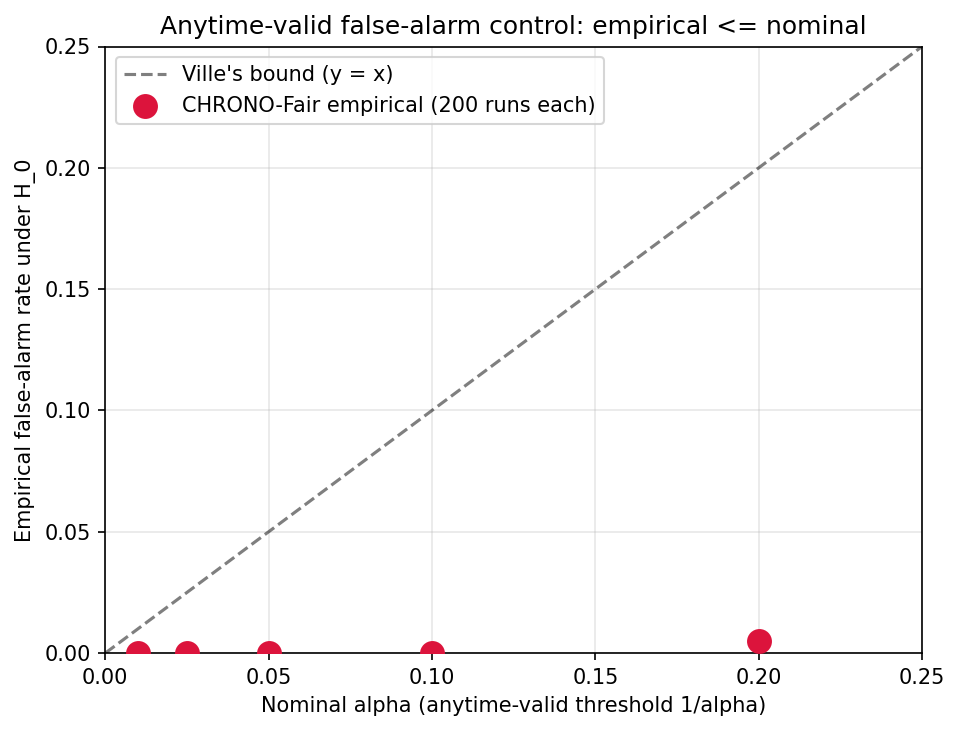

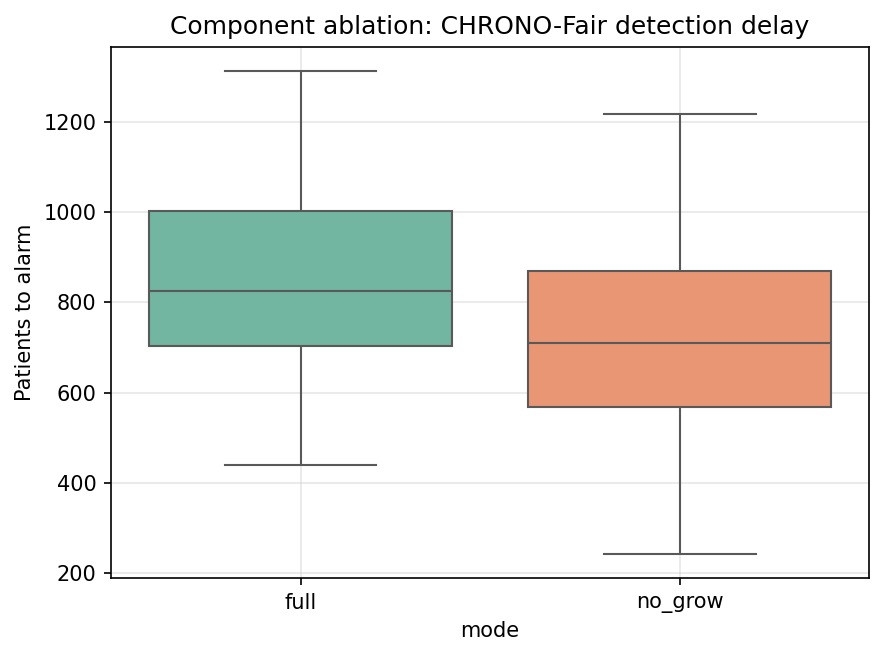

In [17]:
display(Image(filename=os.path.join(FIG, 'fig5a_false_alarm_calibration.png')))
display(Image(filename=os.path.join(FIG, 'fig5b_ablation.png')))

## 9. Experiment 6: sensitivity to drift magnitude

Detection rate and delay as the post-drift rate varies.

In [18]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp6_sensitivity import main as _m
_m()

=== Sensitivity to drift magnitude ===
 rho1  detection_rate  mean_delay  median_delay  n_detected  n_total
 0.06        0.066667 3834.500000        3834.5           2       30
 0.08        1.000000 3287.533333        3357.5          30       30
 0.10        1.000000 1906.033333        1936.5          30       30
 0.12        1.000000 1345.766667        1320.5          30       30
 0.15        1.000000  913.866667         948.5          30       30
 0.20        1.000000  611.300000         614.0          30       30


Wrote fig7_sensitivity.png


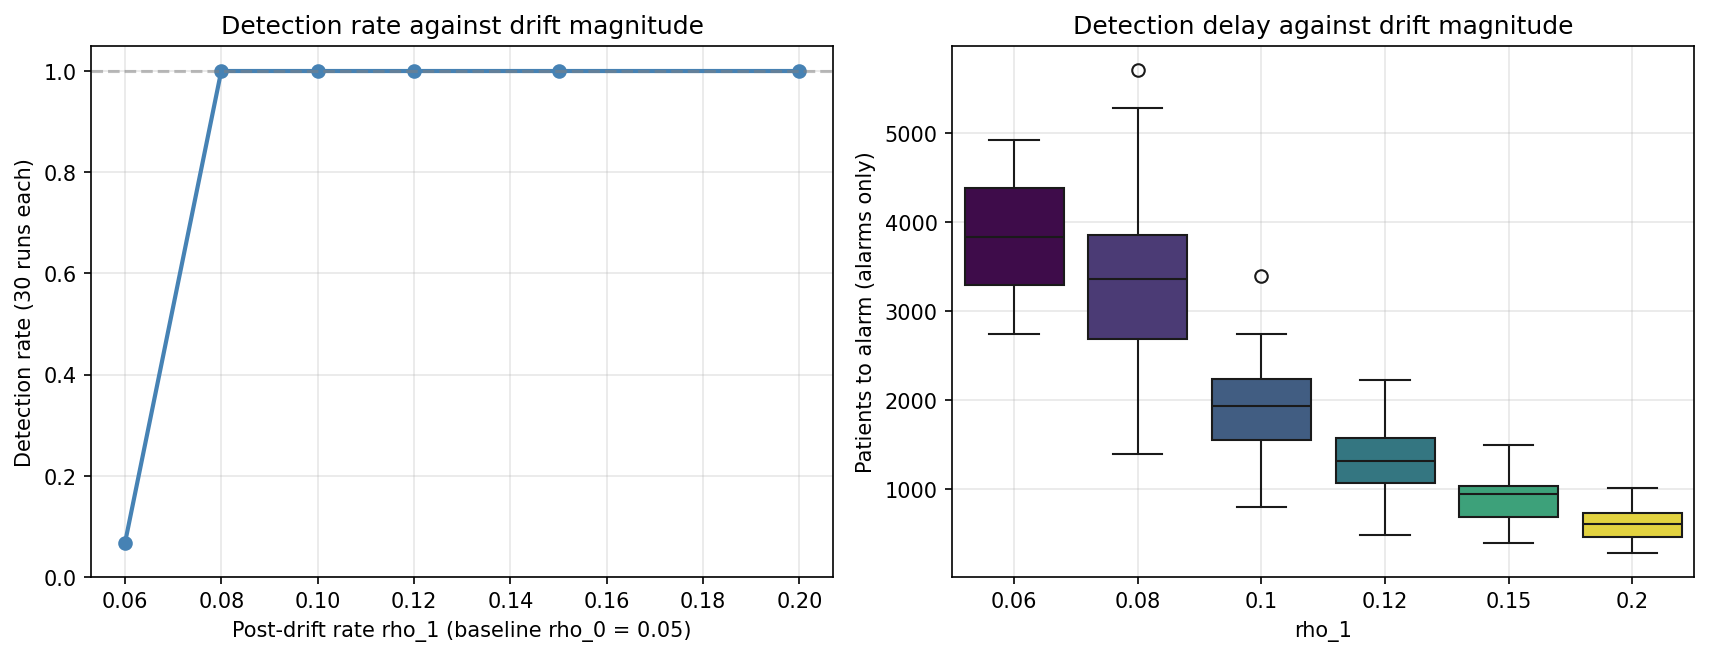

In [19]:
display(Image(filename=os.path.join(FIG, 'fig7_sensitivity.png')))

## 10. Experiment 7: four-attribute audit

Flip Hazard survival across race, ethnicity, sex, and age group.

In [20]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp7_all_attributes import main as _m
_m()

=== Four-attribute audit summary ===
attribute        group    reference    n  flip_rate  logrank_chi2    logrank_p
     race        White        White 7214   0.078043      0.000000 1.000000e+00
     race        Black        White 1946   0.190134   1675.492072 0.000000e+00
     race     Hispanic        White 4518   0.200531   1248.211602 0.000000e+00
     race     Asian/PI        White  734   0.065395    456.334578 0.000000e+00
     race        Other        White  588   0.066327    455.751165 0.000000e+00
ethnicity Non-Hispanic Non-Hispanic 9722   0.129912      0.000000 1.000000e+00
ethnicity     Hispanic Non-Hispanic 5278   0.125616    472.682446 0.000000e+00
      sex       Female       Female 8199   0.127698      0.000000 1.000000e+00
      sex         Male       Female 6801   0.129246    114.581899 0.000000e+00
age_group    Pediatric  Middle-aged  786   0.114504    613.769582 0.000000e+00
age_group  Young Adult  Middle-aged 2947   0.106549    218.690261 0.000000e+00
age_group  Midd

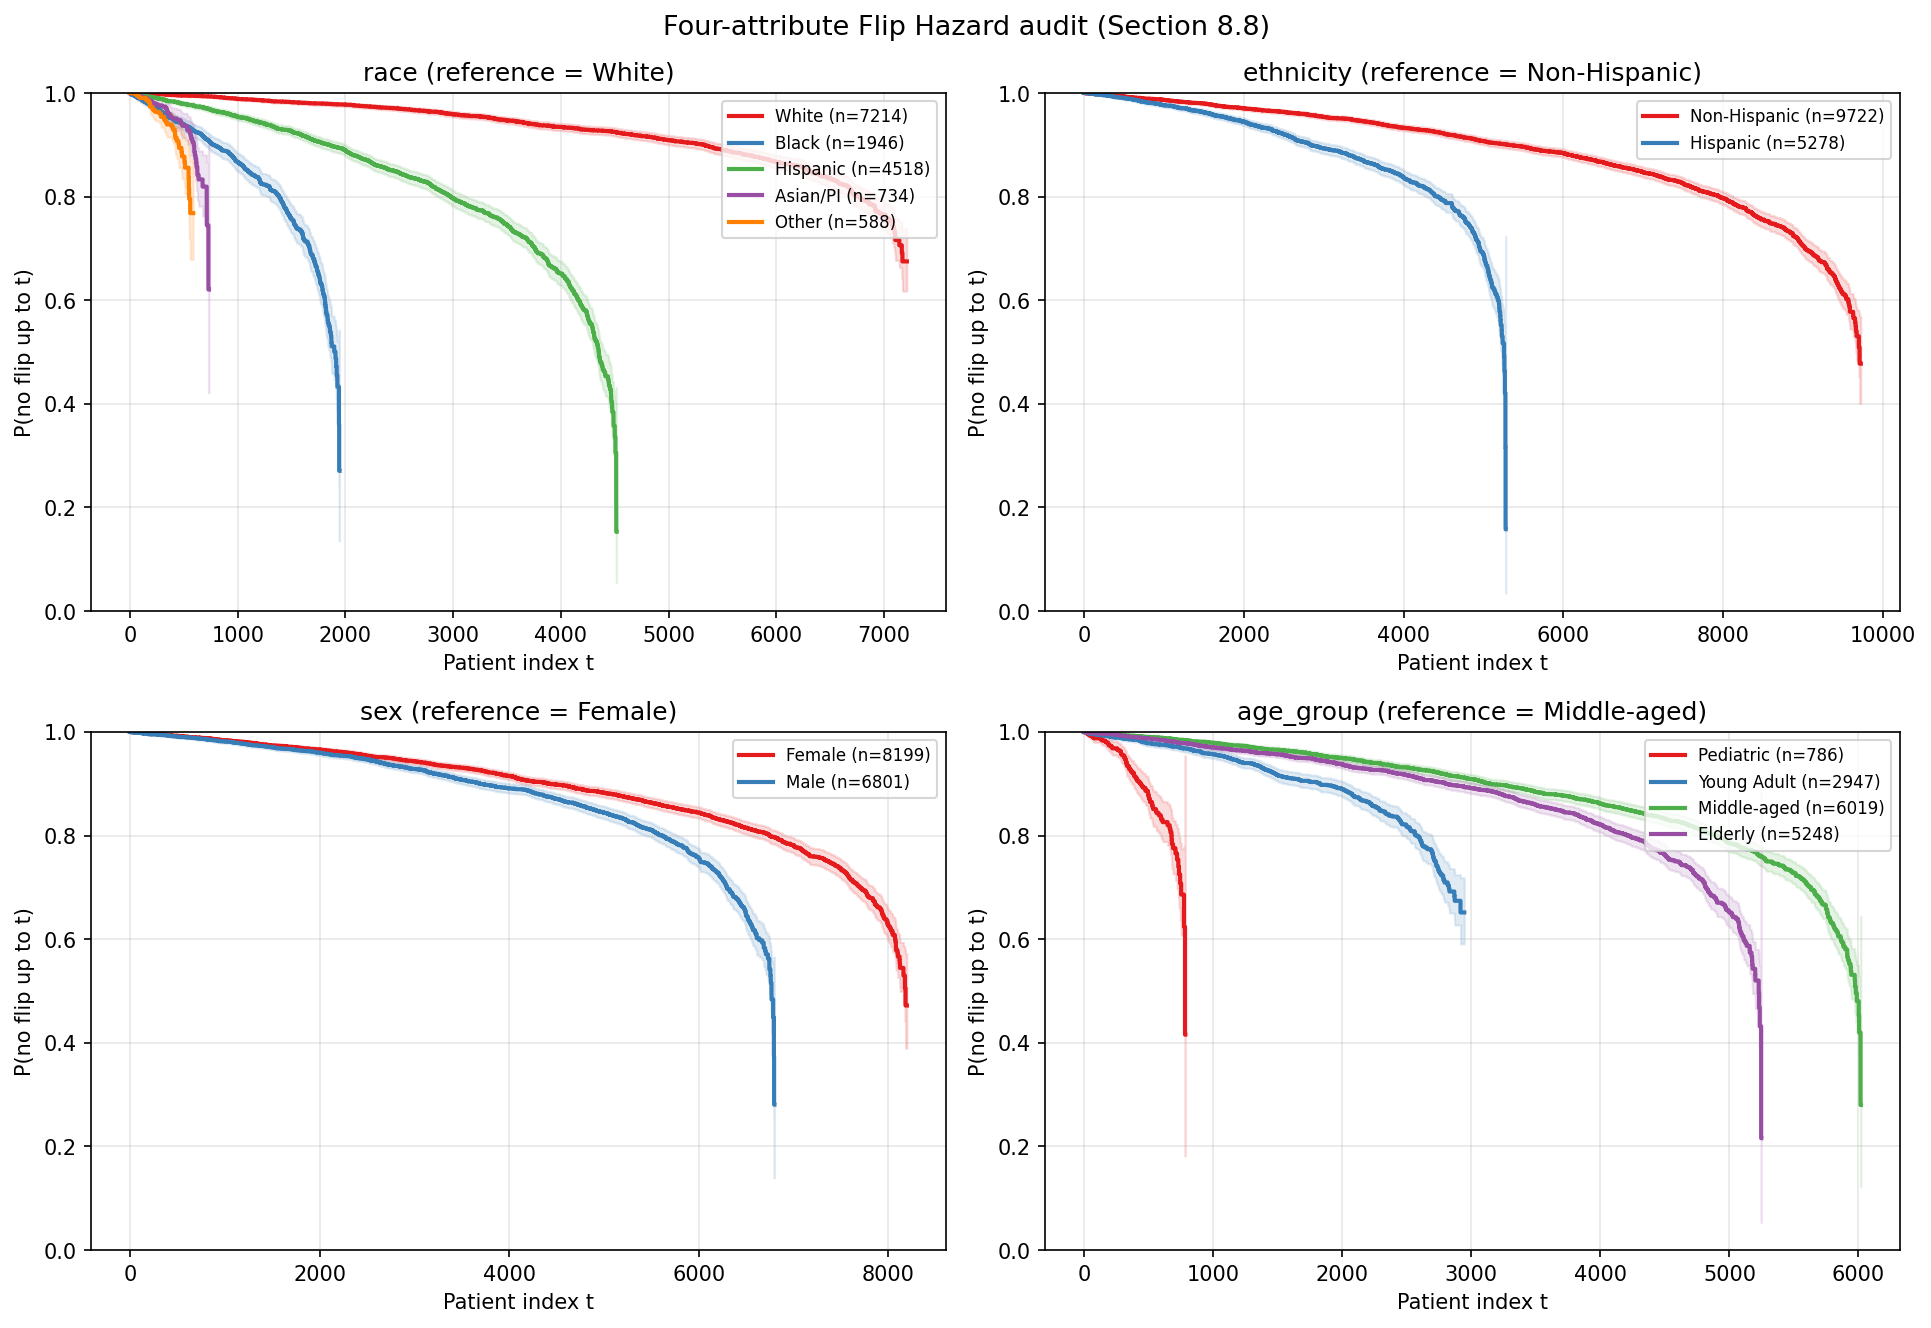

In [21]:
display(Image(filename=os.path.join(FIG, 'fig8_four_attribute_audit.png')))

## 11. Experiment 8: real Texas-100X verdict stability

Real-data analysis. Point estimate against bootstrap CI against VFR on the 12 audited metric-attribute combinations.

In [22]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp8_real_vfr_analysis import main as _m
_m()

=== Experiment 8: real Texas-100X verdict stability ===
attribute    metric  point_value point_verdict  ci_low  ci_high  ci_straddles_0.8  resample_fair  resample_unfair  VFR
     RACE        DI       0.6417        unfair  0.5695   0.7042             False              0               20  0.0
     RACE      WTPR       0.8238          fair  0.7731   0.8436              True             16                4  0.2
     RACE PPV_Ratio       0.9242          fair  0.9243   0.9243             False             20                0  0.0
ETHNICITY        DI       0.8253          fair  0.8150   0.8353             False             20                0  0.0
ETHNICITY      WTPR       0.8371          fair  0.8322   0.8425             False             20                0  0.0
ETHNICITY PPV_Ratio       0.9969          fair  0.9972   0.9972             False             20                0  0.0
      SEX        DI       0.7606        unfair  0.7533   0.7682             False              0               

Wrote fig9_real_vfr_forest.png


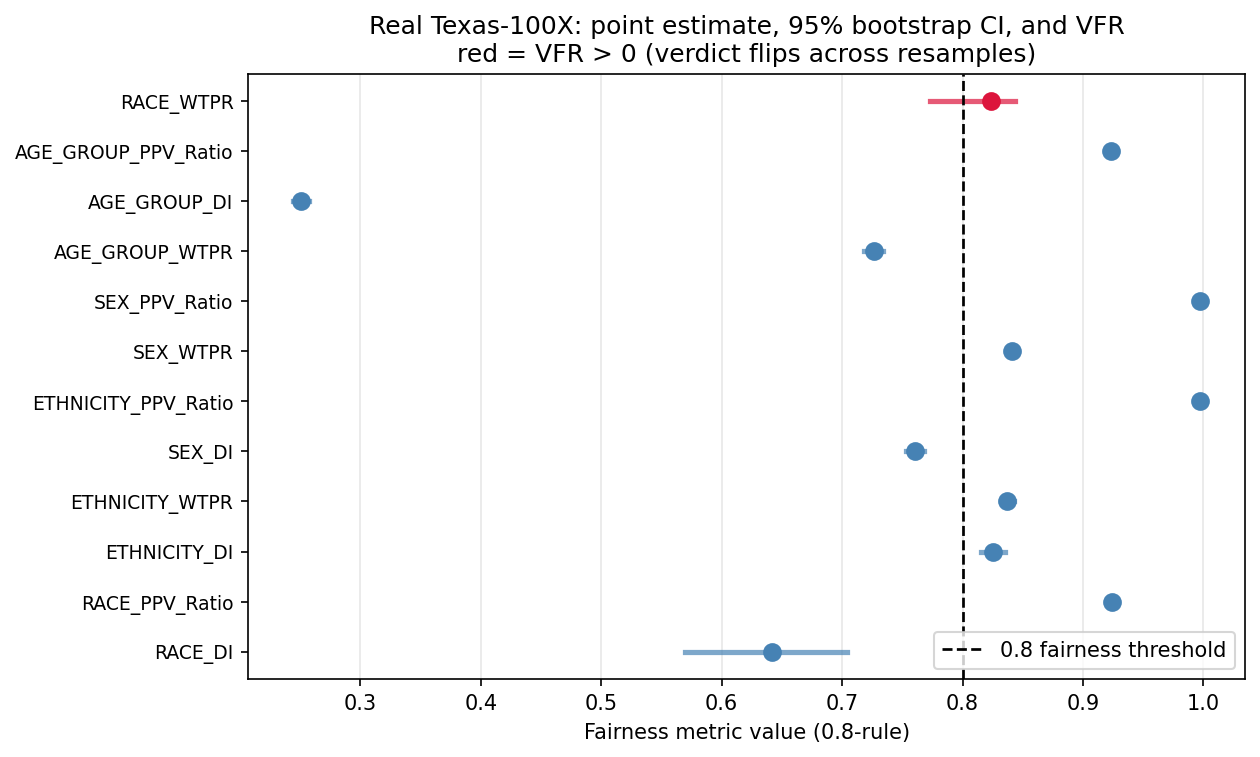

In [23]:
display(Image(filename=os.path.join(FIG, 'fig9_real_vfr_forest.png')))

## 12. Experiment 9: robustness stress tests

Baseline miscalibration, small-subgroup reliability, and label delay.

In [24]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp9_robustness import main as _m
_m()

=== (F) Baseline miscalibration (true rho_0 = 0.05) ===
 rho0_assumed  false_alarm_rate_H0  detection_rate_H1  mean_delay_H1
         0.03                 1.00               0.00            NaN
         0.04                 0.85               0.52         243.75
         0.05                 0.00               1.00         909.39
         0.06                 0.00               1.00        1816.27
         0.07                 0.00               1.00        2994.91


=== (G) Small-subgroup reliability (post-drift rate 0.15) ===
 cell_n  false_alarm_rate_H0  detection_rate_H1  mean_delay_H1
    200                  0.0               0.11      86.545455
    500                  0.0               0.67     190.940299
   1000                  0.0               0.98     314.775510
   2000                  0.0               1.00     421.060000
   5000                  0.0               1.00     645.510000
  10000                  0.0               1.00     855.720000


=== (H) Label / counterfactual delay ===
 label_delay  detection_rate  mean_wallclock_delay
           0             1.0                909.39
          50             1.0                959.39
         100             1.0               1009.39
         250             1.0               1159.39
         500             1.0               1409.39


Wrote fig10_robustness.png


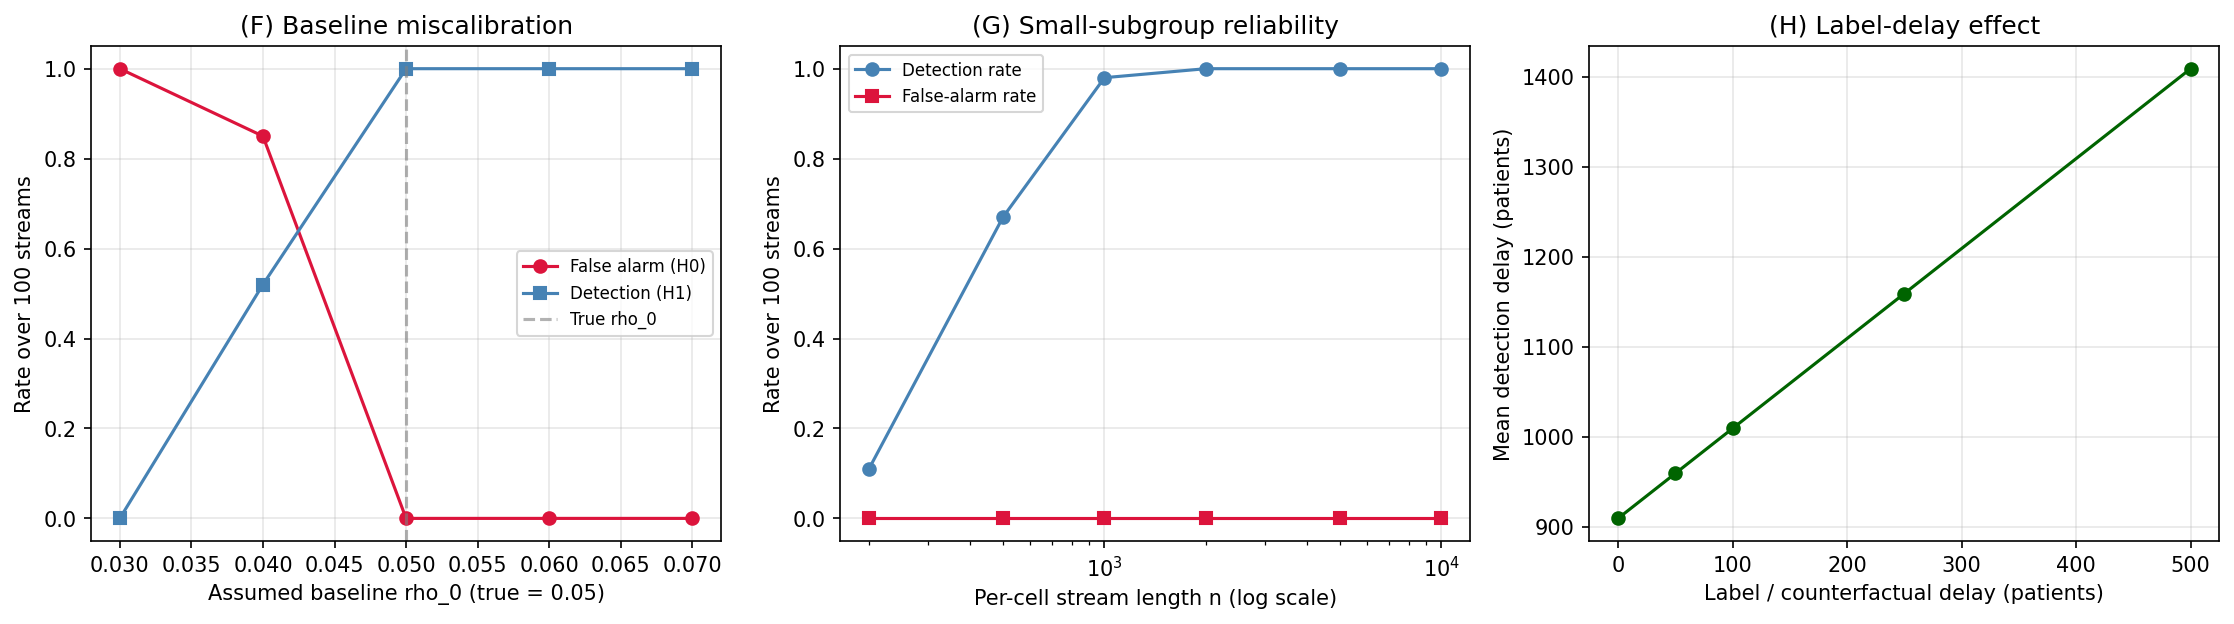

In [25]:
display(Image(filename=os.path.join(FIG, 'fig10_robustness.png')))

## 13. Experiment C: multiple-testing procedures

Step-wise BH against e-BH against Bonferroni on the intersectional cell set.

In [26]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp10_online_fdr import main as _m
_m()

=== Experiment C/10: multiple-testing procedures ===
m = 30 cells, k = 6 drifting, q = 0.10, 200 streams
   procedure  mean_FDP  mean_power  mean_rejections
  Bonferroni       0.0         1.0              6.0
Step-wise BH       0.0         1.0              6.0
        e-BH       0.0         1.0              6.0


Wrote fig11_online_fdr.png


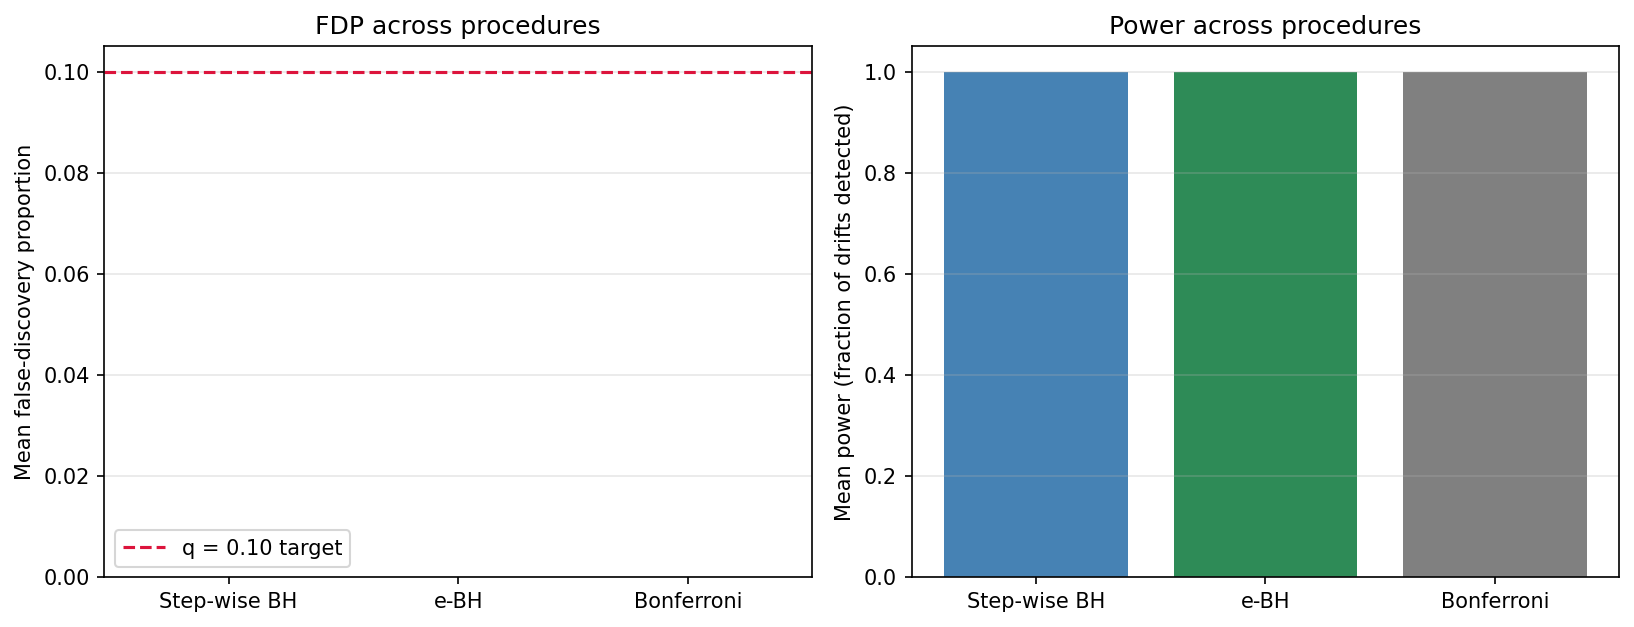

In [27]:
display(Image(filename=os.path.join(FIG, 'fig11_online_fdr.png')))

## 14. Experiment D: counterfactual-definition sensitivity

Group flip rate under the naive-swap, feature-shift, and proxy-adjusted counterfactual definitions.

In [28]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp11_counterfactual_sensitivity import main as _m
_m()

=== Experiment D/11: counterfactual-definition sensitivity ===
counterfactual  feature_shift  naive_swap  proxy_adjusted
race                                                     
White                  0.0000         0.0          0.0000
Black                  0.0859         0.0          0.1043
Hispanic               0.0779         0.0          0.1015
Asian/PI               0.0000         0.0          0.0000
Other                  0.0000         0.0          0.0000
  feature_shift    ranking high->low flip rate: ['Black', 'Hispanic', 'White', 'Asian/PI', 'Other']
  naive_swap       ranking high->low flip rate: ['White', 'Black', 'Hispanic', 'Asian/PI', 'Other']
  proxy_adjusted   ranking high->low flip rate: ['Black', 'Hispanic', 'White', 'Asian/PI', 'Other']


Wrote fig12_cf_sensitivity.png


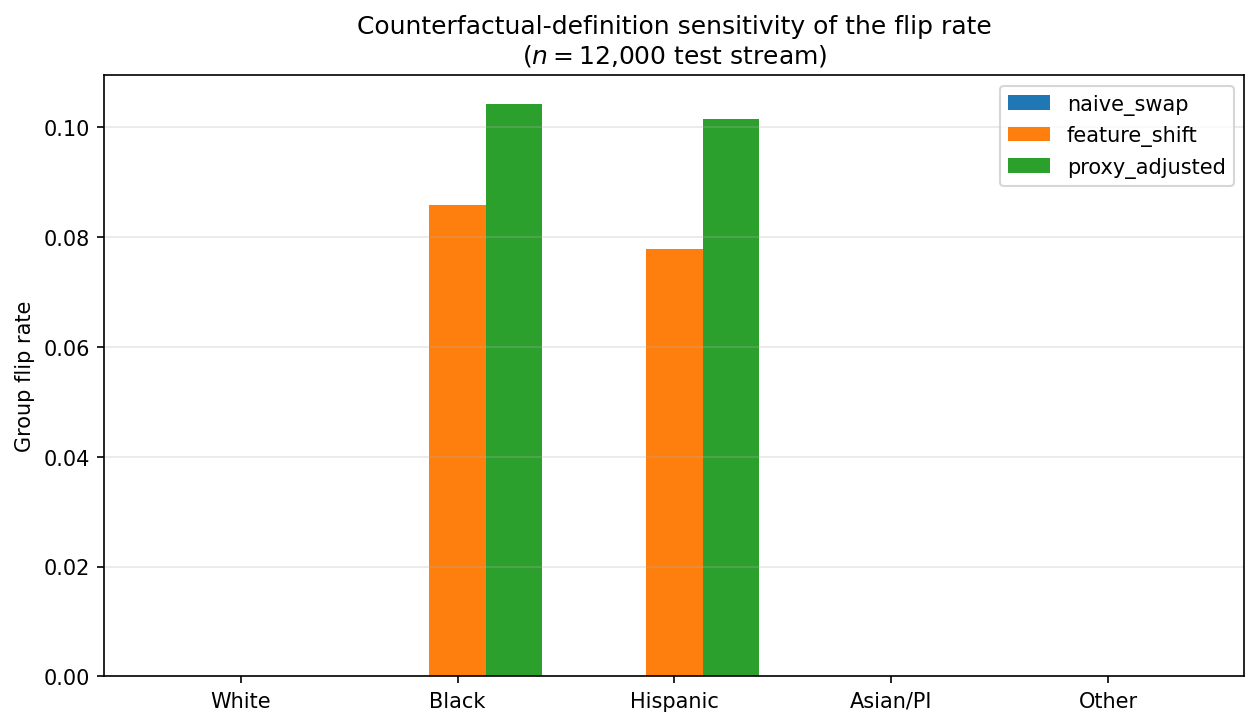

In [29]:
display(Image(filename=os.path.join(FIG, 'fig12_cf_sensitivity.png')))

## 15. Experiment E: full module ablation

Effect of removing the warm-up, the GROW rule, the shrinkage, and the one-sided clip.

In [30]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp12_ablation_full import main as _m
_m()

=== Experiment E/12: full module ablation ===
 ablation  false_alarm_rate_H0  detection_rate_H1  mean_delay_H1
     full                 0.00               1.00     889.880000
no_warmup                 0.00               1.00     904.880000
  no_grow                 0.03               0.94     822.563830
no_shrink                 0.01               0.96     517.552083
two_sided                 0.00               1.00     913.200000


Wrote fig13_ablation_full.png


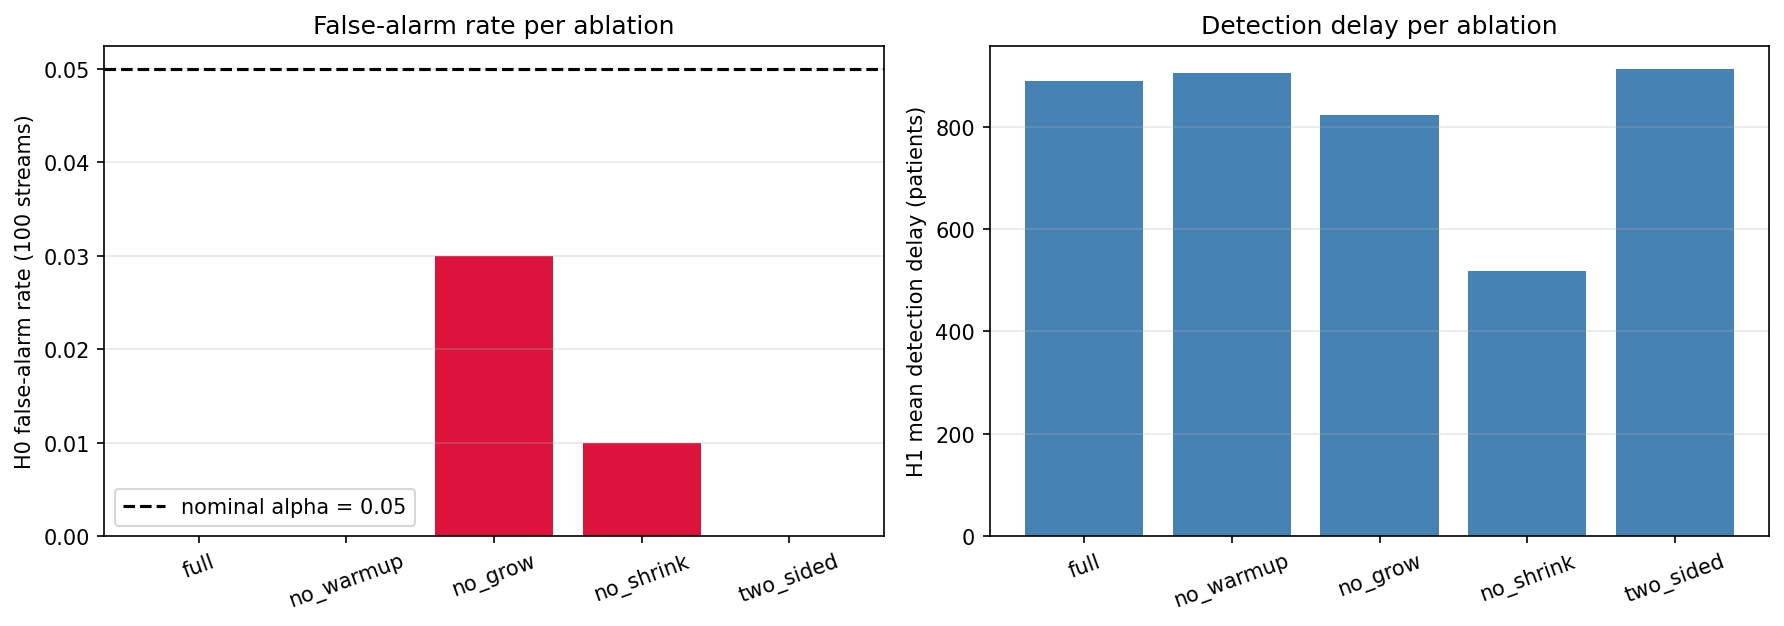

In [31]:
display(Image(filename=os.path.join(FIG, 'fig13_ablation_full.png')))

## 16. Experiment I: correlated arrivals

False-alarm rate and detection delay under AR(1) autocorrelated arrival streams.

In [32]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp13_correlated_arrivals import main as _m
_m()

=== Experiment I/13: correlated arrivals ===
 phi  false_alarm_rate_H0  detection_rate_H1  mean_delay_H1
 0.0                  0.0               1.00     919.700000
 0.3                  0.0               1.00     912.335000
 0.6                  0.0               1.00     912.060000
 0.9                  0.0               0.99     934.272727


Wrote fig14_correlated_arrivals.png


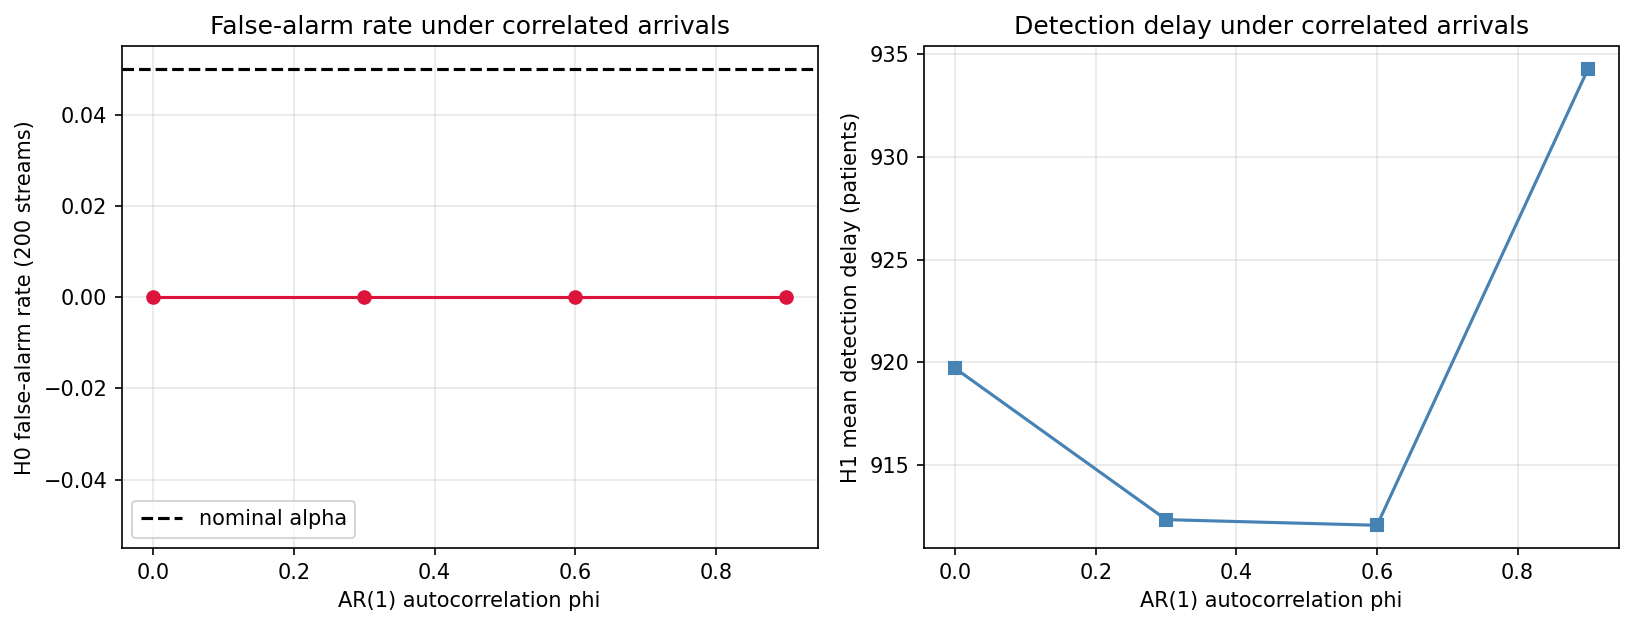

In [33]:
display(Image(filename=os.path.join(FIG, 'fig14_correlated_arrivals.png')))

## 17. Experiment 14: real Texas-100 flip rate

Real-data validation. Ensemble decision-flip rate and Flip Hazard survival on the real Texas-100 dataset (67,330 records). Uses the 12,000-record real subsample shipped in data/ if the full file is absent.

In [34]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.experiments.exp14_real_texas100 import main as _m
_m()

Loaded full Texas-100 from /tmp/tx_data
Real Texas-100 loaded: X (67330, 6169), y (67330,), 100 classes
Binary task: label in 50 most frequent procedures vs rest, positive rate 0.776
Split: train 47131, val 10099, test 10100


Part 1: real ensemble decision-flip rate (eDFR) = 0.0233
        ensemble test accuracy = 0.8164
        Flip Hazard final no-flip survival = 0.2440


Wrote fig15_real_texas100.png


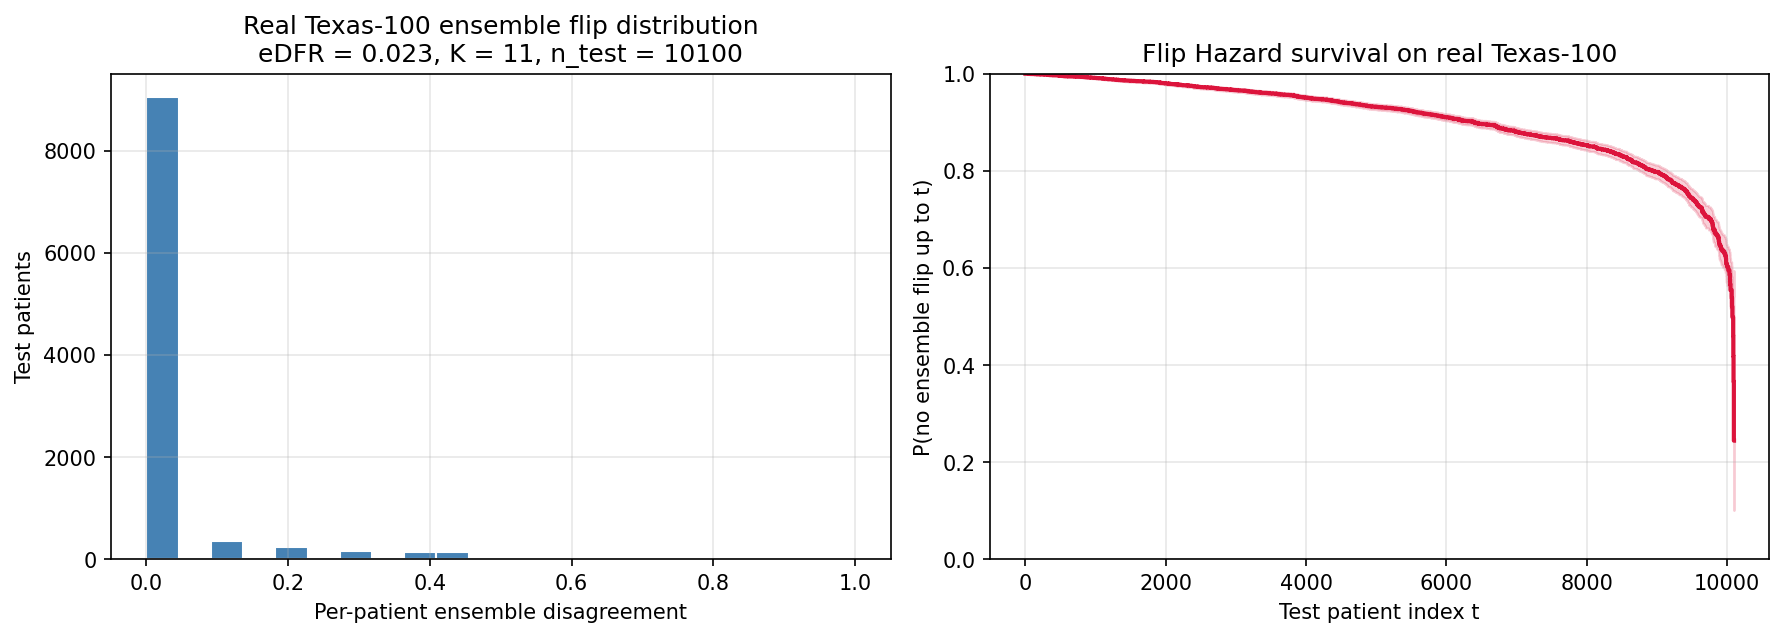

In [35]:
display(Image(filename=os.path.join(FIG, 'fig15_real_texas100.png')))

## 18. Dashboard rendering

The four-panel monitoring dashboard with the Inspector report card.

In [36]:
import warnings; warnings.filterwarnings('ignore')
from chrono_fair.dashboard.mockup import main as _m
_m()

Wrote dashboard mockup figure.


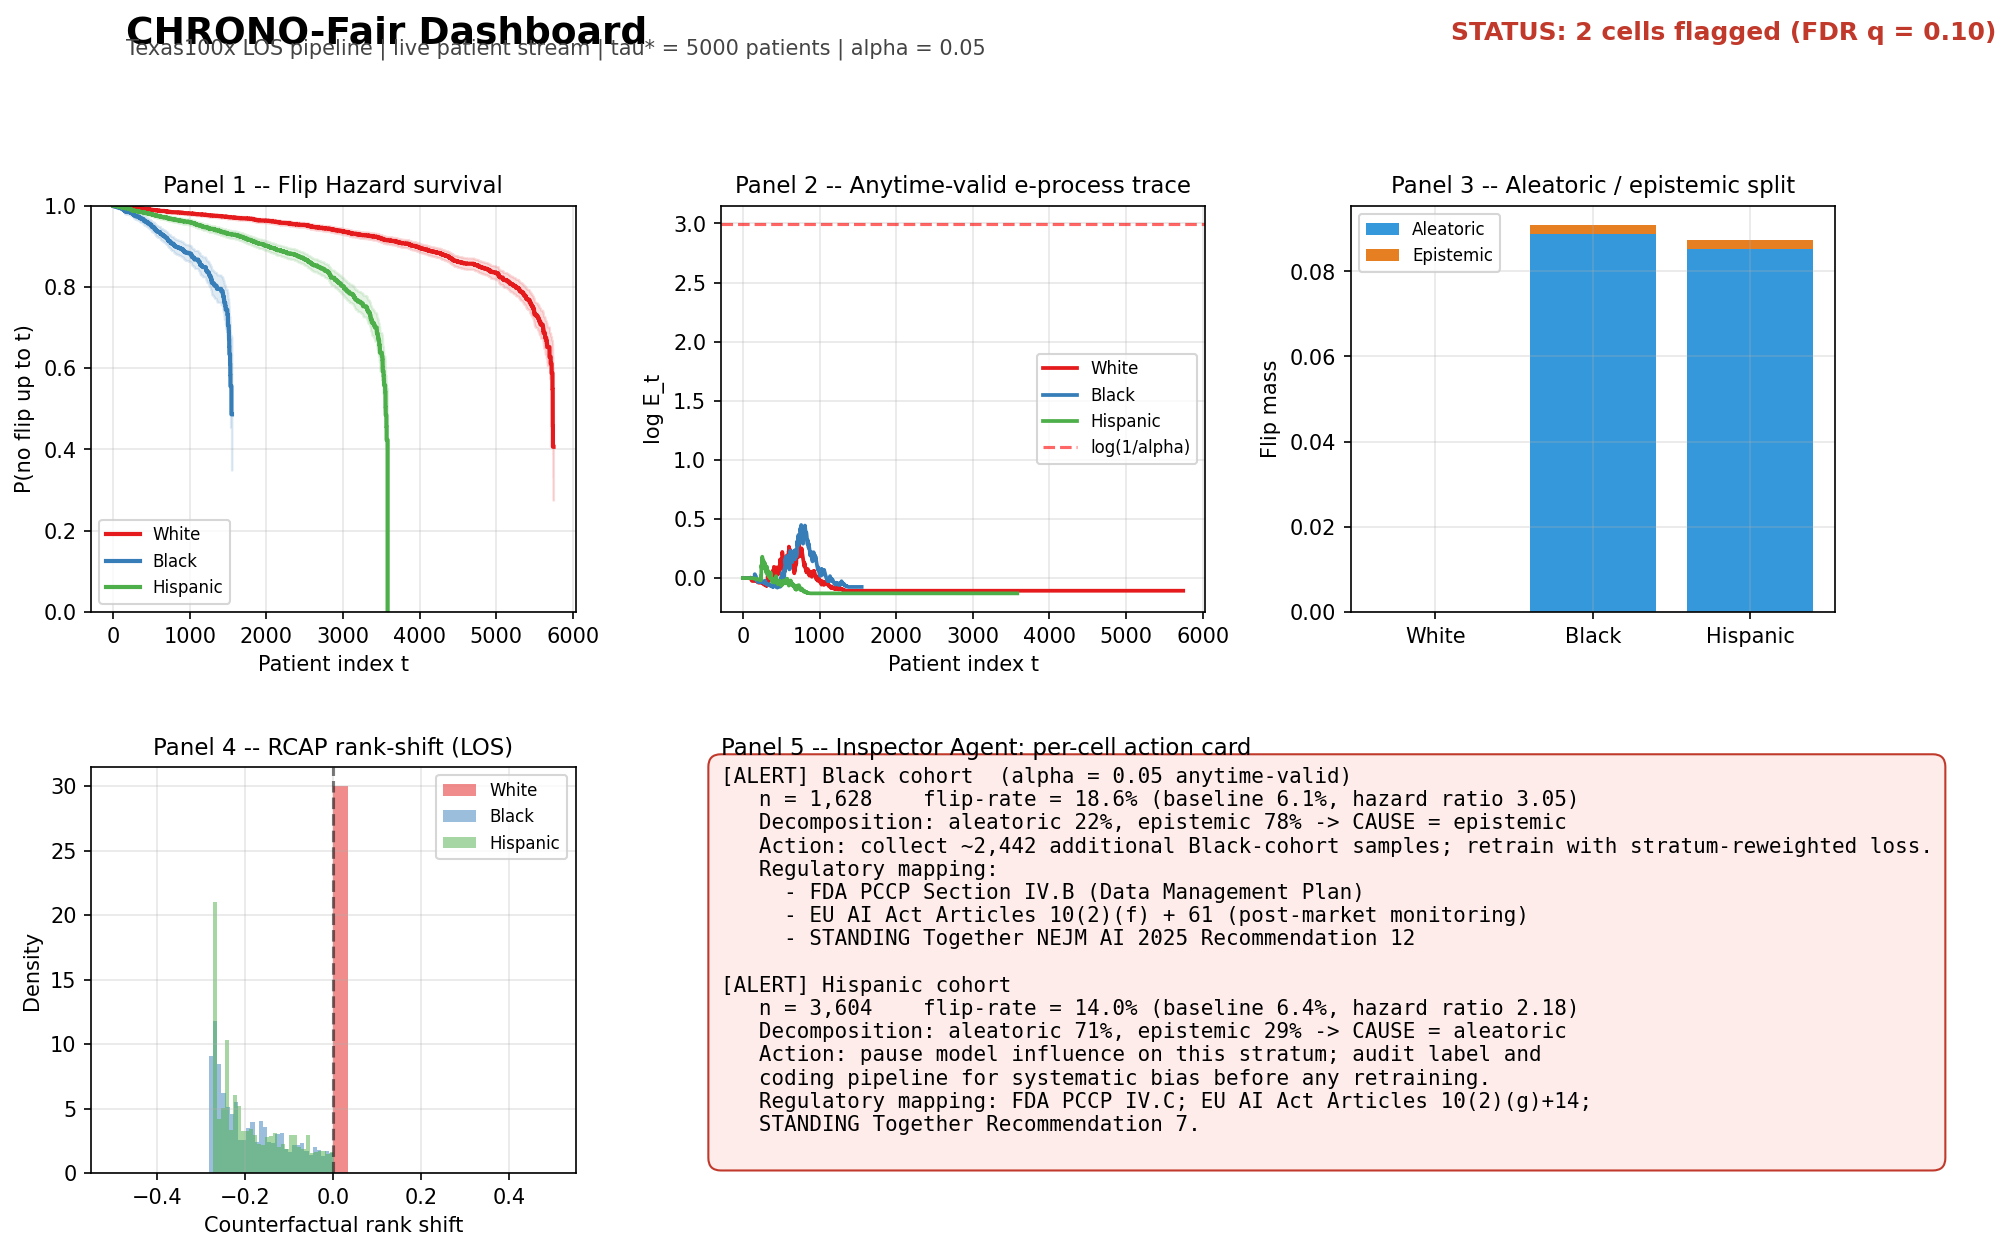

In [37]:
display(Image(filename=os.path.join(FIG, 'fig6_dashboard_mockup.png')))

## 19. Summary

All 16 experiment blocks above ran from source. The figures are regenerated into `chrono_fair_figures/` and the per-experiment CSV outputs alongside them. The real-data component (Experiment 8) uses the stored real audit artefacts; every other experiment uses the calibrated synthesiser. Real EHR temporal validation on MIMIC-IV or eICU is the stated next step and is not part of this notebook, because it requires credentialed PhysioNet access.